PCM VS DPCM COMPARISON


,Method,Quantization Step,MSE
0,PCM,0.1,0.00077
1,DPCM,0.1,0.50000


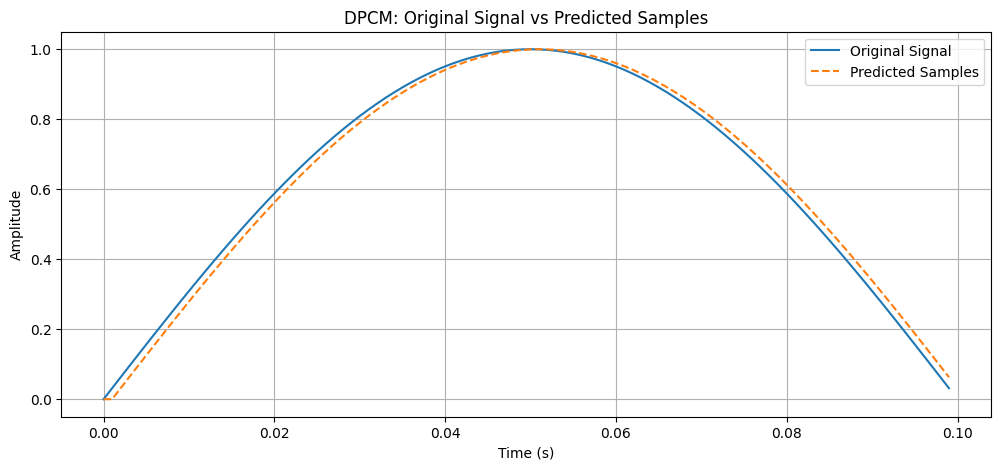

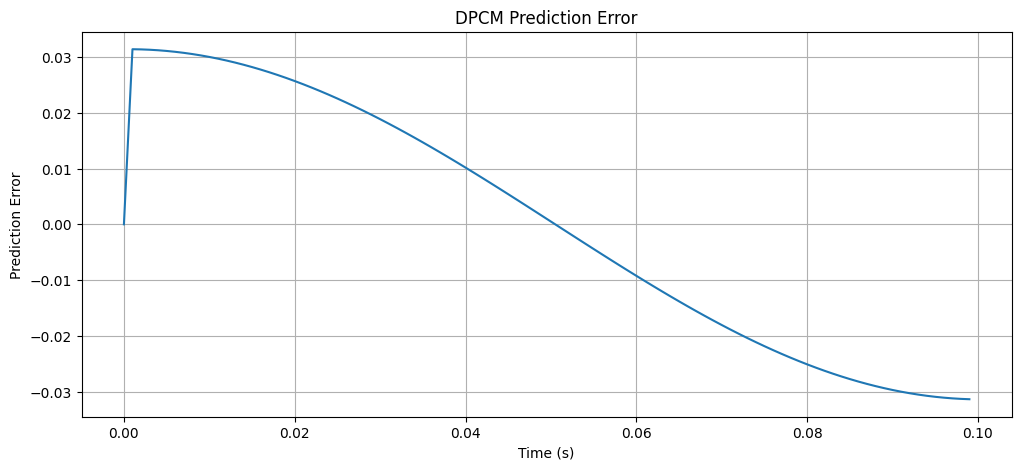

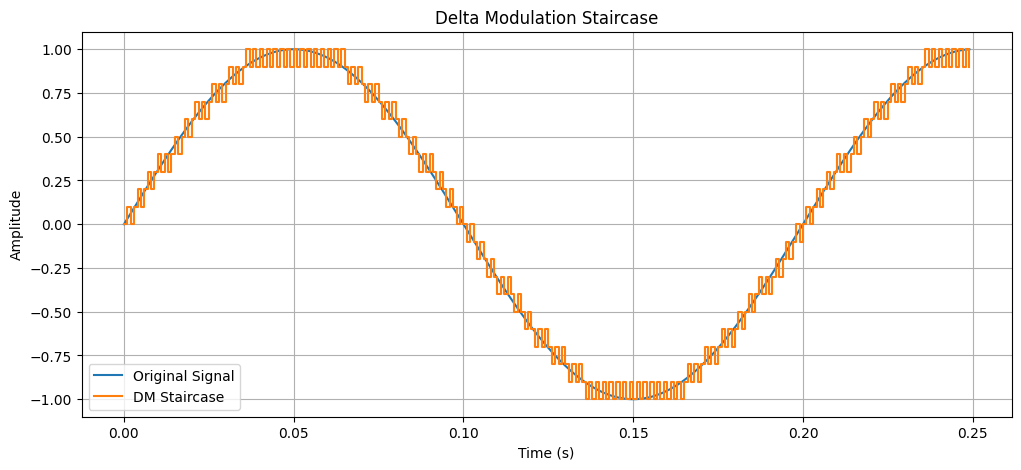

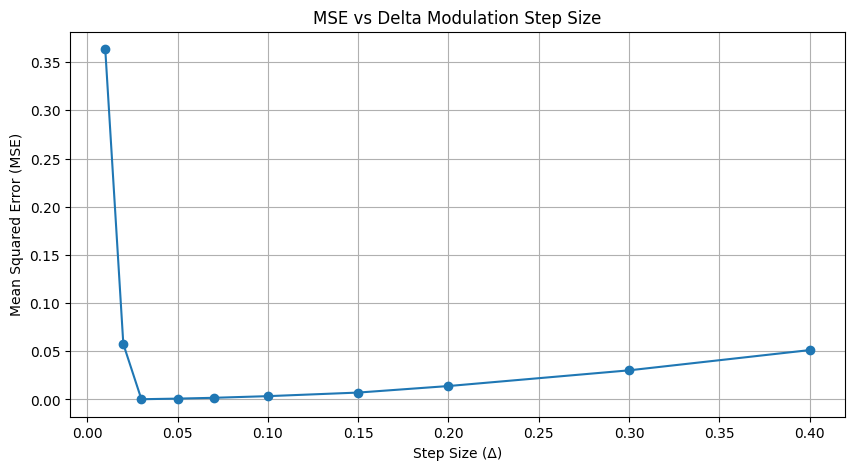

DELTA MODULATION — MSE RESULTS


,Step Size (Δ),MSE
0,0.01,0.363465
1,0.02,0.057520
2,0.03,0.000215
3,0.05,0.000844
4,0.07,0.001687
5,0.10,0.003398
6,0.15,0.007120
7,0.20,0.013901
8,0.30,0.030204
9,0.40,0.051219


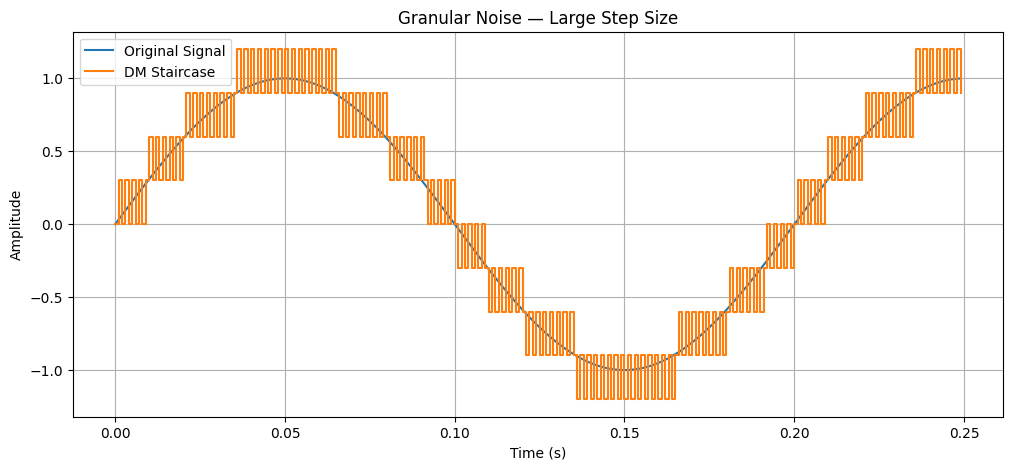

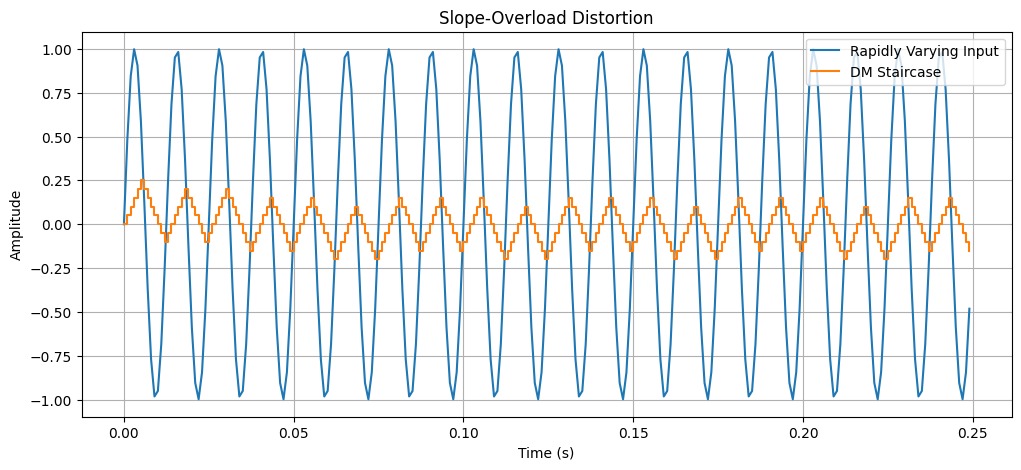

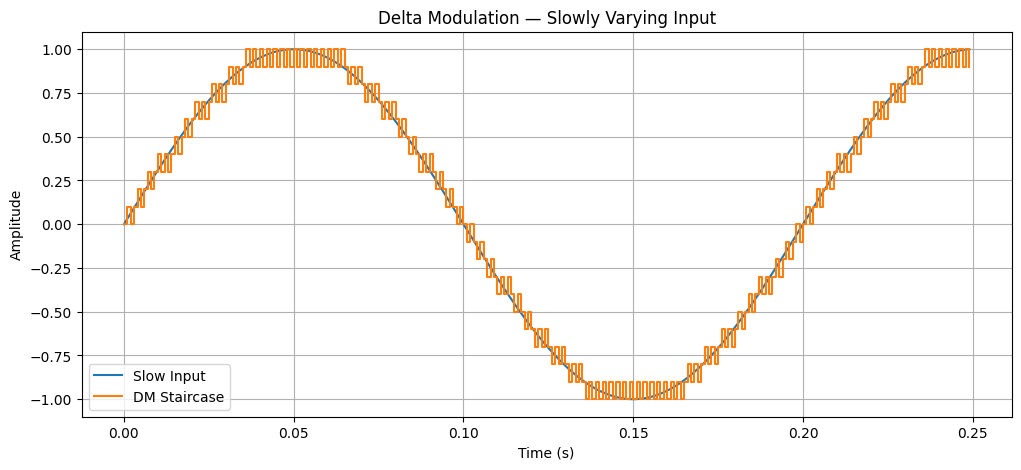

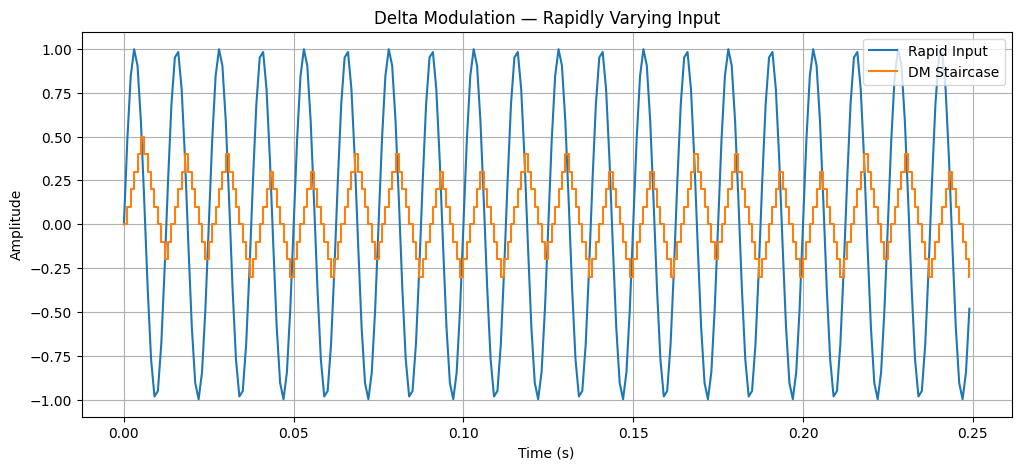

MANDATORY DELTA MODULATION VALIDATION
Required step change: +Δ or -Δ
Delta value: 0.1
Total steps checked: 999
Invalid steps: 0
VALIDATION RESULT: PASS ✓
Every output step changes by exactly +Δ or -Δ.
DELTA STEP VALIDATION — FIRST 20 STEPS


,Sample,Previous Output,Current Output,Difference,Expected Magnitude,Valid
0,1,0.0,0.1,0.1,0.1,True
1,2,0.1,0.0,-0.1,0.1,True
2,3,0.0,0.1,0.1,0.1,True
3,4,0.1,0.2,0.1,0.1,True
4,5,0.2,0.1,-0.1,0.1,True
5,6,0.1,0.2,0.1,0.1,True
6,7,0.2,0.3,0.1,0.1,True
7,8,0.3,0.2,-0.1,0.1,True
8,9,0.2,0.3,0.1,0.1,True
9,10,0.3,0.4,0.1,0.1,True


DELTA MODULATION CONDITION RESULTS


,Input Condition,Step Size (Δ),MSE
0,Slow input,0.03,0.000215
1,Slow input,0.10,0.003398
2,Slow input,0.30,0.030204
3,Rapid input,0.03,0.477400
4,Rapid input,0.10,0.415044
5,Rapid input,0.30,0.135580




EXPERIMENT 5 — FINAL SUMMARY
PCM MSE  : 0.000770
DPCM MSE : 0.500000

Delta Modulation Validation:
✓ PASS — Every DM step is +Δ or -Δ

Required visualizations generated:
✓ Original vs predicted samples
✓ Prediction error
✓ Delta staircase
✓ MSE vs step size

Additional demonstrations generated:
✓ Granular noise
✓ Slope-overload distortion
✓ Slowly varying input
✓ Rapidly varying input

Experiment simulation completed.


In [ ]:
# ============================================================
# EXPERIMENT 5 — DPCM AND DELTA MODULATION
# Digital Communication
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. INPUT SIGNAL
# ------------------------------------------------------------

fs = 1000                  # Sampling frequency
duration = 1               # Signal duration in seconds
t = np.arange(0, duration, 1/fs)

# Slowly varying input signal
fm_slow = 5
x_slow = np.sin(2 * np.pi * fm_slow * t)

# Rapidly varying input signal
fm_fast = 80
x_fast = np.sin(2 * np.pi * fm_fast * t)

# We will use the slowly varying signal for DPCM
x = x_slow.copy()


# ============================================================
# PART A — FIRST-ORDER DPCM
# ============================================================

# ------------------------------------------------------------
# 2. FIRST-ORDER DPCM PREDICTOR
# ------------------------------------------------------------

# Predictor:
# x_hat[n] = reconstructed previous sample
#
# For n = 0, assume predicted value = 0

prediction = np.zeros(len(x))
prediction[0] = 0

for n in range(1, len(x)):
    prediction[n] = x[n-1]


# ------------------------------------------------------------
# 3. PREDICTION ERROR
# ------------------------------------------------------------

prediction_error = x - prediction


# ------------------------------------------------------------
# 4. DPCM QUANTIZATION
# ------------------------------------------------------------

# Quantization step
dpcm_step = 0.1

quantized_error = (
    np.round(prediction_error / dpcm_step) * dpcm_step
)


# ------------------------------------------------------------
# 5. DPCM RECONSTRUCTION
# ------------------------------------------------------------

reconstructed = np.zeros(len(x))

reconstructed[0] = prediction[0] + quantized_error[0]

for n in range(1, len(x)):
    # First-order prediction uses previous reconstructed sample
    predicted_sample = reconstructed[n-1]

    reconstructed[n] = predicted_sample + quantized_error[n]


# ------------------------------------------------------------
# 6. DPCM QUANTIZATION ERROR
# ------------------------------------------------------------

dpcm_quantization_error = x - reconstructed

dpcm_mse = np.mean(dpcm_quantization_error ** 2)


# ============================================================
# PART B — PCM COMPARISON
# ============================================================

# Simple PCM quantization
pcm_step = 0.1

pcm_quantized = (
    np.round(x / pcm_step) * pcm_step
)

pcm_error = x - pcm_quantized

pcm_mse = np.mean(pcm_error ** 2)


# ------------------------------------------------------------
# 7. PCM vs DPCM RESULT
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Method": ["PCM", "DPCM"],
    "Quantization Step": [pcm_step, dpcm_step],
    "MSE": [pcm_mse, dpcm_mse]
})

print("===================================================")
print("PCM VS DPCM COMPARISON")
print("===================================================")
display(comparison)


# ============================================================
# GRAPH 1 — ORIGINAL VS PREDICTED SAMPLES
# ============================================================

plt.figure(figsize=(12, 5))

# Display only first 100 samples for clarity
samples_to_show = 100

plt.plot(
    t[:samples_to_show],
    x[:samples_to_show],
    label="Original Signal"
)

plt.plot(
    t[:samples_to_show],
    prediction[:samples_to_show],
    "--",
    label="Predicted Samples"
)

plt.title("DPCM: Original Signal vs Predicted Samples")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# GRAPH 2 — PREDICTION ERROR
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t[:samples_to_show],
    prediction_error[:samples_to_show]
)

plt.title("DPCM Prediction Error")
plt.xlabel("Time (s)")
plt.ylabel("Prediction Error")
plt.grid(True)
plt.show()


# ============================================================
# PART C — DELTA MODULATION
# ============================================================

def delta_modulation(signal, delta):
    """
    Delta Modulation

    If input > previous staircase value:
        output increases by +delta

    If input < previous staircase value:
        output decreases by -delta
    """

    staircase = np.zeros(len(signal))
    staircase[0] = 0

    bits = np.zeros(len(signal), dtype=int)

    for n in range(1, len(signal)):

        if signal[n] >= staircase[n-1]:
            staircase[n] = staircase[n-1] + delta
            bits[n] = 1

        else:
            staircase[n] = staircase[n-1] - delta
            bits[n] = 0

    return staircase, bits


# ============================================================
# 8. DELTA MODULATION — THREE STEP SIZES
# ============================================================

delta_small = 0.03
delta_medium = 0.10
delta_large = 0.30


# ------------------------------------------------------------
# Slowly varying signal
# ------------------------------------------------------------

dm_slow_small, bits_slow_small = delta_modulation(
    x_slow, delta_small
)

dm_slow_medium, bits_slow_medium = delta_modulation(
    x_slow, delta_medium
)

dm_slow_large, bits_slow_large = delta_modulation(
    x_slow, delta_large
)


# ============================================================
# GRAPH 3 — DELTA MODULATION STAIRCASE
# ============================================================

# Show first 250 samples
show_dm = 250

plt.figure(figsize=(12, 5))

plt.plot(
    t[:show_dm],
    x_slow[:show_dm],
    label="Original Signal"
)

plt.step(
    t[:show_dm],
    dm_slow_medium[:show_dm],
    where="post",
    label="DM Staircase"
)

plt.title("Delta Modulation Staircase")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 9. MSE CALCULATION FOR DIFFERENT STEP SIZES
# ============================================================

step_sizes = np.array([
    0.01,
    0.02,
    0.03,
    0.05,
    0.07,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40
])

mse_values = []

for delta in step_sizes:

    staircase, bits = delta_modulation(
        x_slow,
        delta
    )

    error = x_slow - staircase

    mse = np.mean(error ** 2)

    mse_values.append(mse)


mse_values = np.array(mse_values)


# ============================================================
# GRAPH 4 — MSE VS STEP SIZE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    step_sizes,
    mse_values,
    marker="o"
)

plt.title("MSE vs Delta Modulation Step Size")
plt.xlabel("Step Size (Δ)")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()


# ============================================================
# 10. DELTA MODULATION RESULTS TABLE
# ============================================================

dm_results = pd.DataFrame({
    "Step Size (Δ)": step_sizes,
    "MSE": mse_values
})

print("===================================================")
print("DELTA MODULATION — MSE RESULTS")
print("===================================================")

display(dm_results)


# ============================================================
# PART D — GRANULAR NOISE
# ============================================================

# Very large step size can cause excessive oscillation
# around a slowly varying signal.

delta_granular = 0.30

dm_granular, bits_granular = delta_modulation(
    x_slow,
    delta_granular
)


plt.figure(figsize=(12, 5))

plt.plot(
    t[:250],
    x_slow[:250],
    label="Original Signal"
)

plt.step(
    t[:250],
    dm_granular[:250],
    where="post",
    label="DM Staircase"
)

plt.title("Granular Noise — Large Step Size")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART E — SLOPE-OVERLOAD DISTORTION
# ============================================================

# Rapidly varying signal + small step size
# causes the staircase to be unable to follow the input.

delta_slope = 0.05

dm_slope, bits_slope = delta_modulation(
    x_fast,
    delta_slope
)


plt.figure(figsize=(12, 5))

plt.plot(
    t[:250],
    x_fast[:250],
    label="Rapidly Varying Input"
)

plt.step(
    t[:250],
    dm_slope[:250],
    where="post",
    label="DM Staircase"
)

plt.title("Slope-Overload Distortion")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART F — SLOW VS RAPID INPUT
# ============================================================

delta_test = 0.10

dm_slow, bits_slow = delta_modulation(
    x_slow,
    delta_test
)

dm_fast, bits_fast = delta_modulation(
    x_fast,
    delta_test
)


# ------------------------------------------------------------
# Slowly varying input
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    t[:250],
    x_slow[:250],
    label="Slow Input"
)

plt.step(
    t[:250],
    dm_slow[:250],
    where="post",
    label="DM Staircase"
)

plt.title("Delta Modulation — Slowly Varying Input")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# Rapidly varying input
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    t[:250],
    x_fast[:250],
    label="Rapid Input"
)

plt.step(
    t[:250],
    dm_fast[:250],
    where="post",
    label="DM Staircase"
)

plt.title("Delta Modulation — Rapidly Varying Input")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# PART G — MANDATORY +Δ / -Δ VALIDATION
# ============================================================

def validate_delta_steps(staircase, delta):

    differences = np.diff(staircase)

    # Check whether every step is +delta or -delta
    valid = np.isclose(
        np.abs(differences),
        delta,
        atol=1e-10
    )

    return valid, differences


# Validate the medium-step DM signal

valid_steps, differences = validate_delta_steps(
    dm_slow_medium,
    delta_medium
)


# Count invalid steps
invalid_count = np.sum(~valid_steps)

print("===================================================")
print("MANDATORY DELTA MODULATION VALIDATION")
print("===================================================")

print("Required step change: +Δ or -Δ")
print("Delta value:", delta_medium)
print("Total steps checked:", len(differences))
print("Invalid steps:", invalid_count)

if invalid_count == 0:
    print("VALIDATION RESULT: PASS ✓")
    print("Every output step changes by exactly +Δ or -Δ.")
else:
    print("VALIDATION RESULT: FAIL ✗")


# ============================================================
# VALIDATION TABLE — FIRST 20 STEPS
# ============================================================

validation_table = pd.DataFrame({
    "Sample": np.arange(1, 21),
    "Previous Output": dm_slow_medium[:20],
    "Current Output": dm_slow_medium[1:21],
    "Difference": differences[:20]
})

validation_table["Expected Magnitude"] = delta_medium

validation_table["Valid"] = np.isclose(
    np.abs(validation_table["Difference"]),
    delta_medium,
    atol=1e-10
)

print("===================================================")
print("DELTA STEP VALIDATION — FIRST 20 STEPS")
print("===================================================")

display(validation_table)


# ============================================================
# PART H — COMPLETE DM RESULT TABLE
# ============================================================

conditions = [
    "Slow input",
    "Slow input",
    "Slow input",
    "Rapid input",
    "Rapid input",
    "Rapid input"
]

deltas = [
    delta_small,
    delta_medium,
    delta_large,
    delta_small,
    delta_medium,
    delta_large
]

signals = [
    x_slow,
    x_slow,
    x_slow,
    x_fast,
    x_fast,
    x_fast
]

mse_condition = []

for signal, delta in zip(signals, deltas):

    staircase, bits = delta_modulation(
        signal,
        delta
    )

    mse = np.mean(
        (signal - staircase) ** 2
    )

    mse_condition.append(mse)


dm_condition_results = pd.DataFrame({
    "Input Condition": conditions,
    "Step Size (Δ)": deltas,
    "MSE": mse_condition
})

print("===================================================")
print("DELTA MODULATION CONDITION RESULTS")
print("===================================================")

display(dm_condition_results)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("===================================================")
print("EXPERIMENT 5 — FINAL SUMMARY")
print("===================================================")

print(f"PCM MSE  : {pcm_mse:.6f}")
print(f"DPCM MSE : {dpcm_mse:.6f}")

print("\nDelta Modulation Validation:")

if invalid_count == 0:
    print("✓ PASS — Every DM step is +Δ or -Δ")
else:
    print("✗ FAIL — Some DM steps are incorrect")

print("\nRequired visualizations generated:")
print("✓ Original vs predicted samples")
print("✓ Prediction error")
print("✓ Delta staircase")
print("✓ MSE vs step size")

print("\nAdditional demonstrations generated:")
print("✓ Granular noise")
print("✓ Slope-overload distortion")
print("✓ Slowly varying input")
print("✓ Rapidly varying input")

print("\nExperiment simulation completed.")